# Class exercise: Ice cream cone

```{custom_download_link} ./moo.ipynb
:replace_default: "True"
```

```{figure} ./figures/ice_cone.png
:name: cone
:width: 300px
ice cone
```

We want to minimize the surface area of a cone, while not making the gap on the top too big (in terms of area).
Let’s define this as a multi-objective optimization problem with
1. the first objective to minimize the ice cream cone area $\pi r \sqrt{r^2+h^2}$
2. the second objective to minimize the ice cream cone area + the area of the gap $\pi r \sqrt{r^2+h^2} + \pi r^2$.

The total volume inside the cone must be at least 200.

Find the pareto front using normalized objective functions


```{exercise-start} Model
:label: ice_cone_model
```

Write out the model of this problem.

```{exercise-end}
```

```{solution-start} ice_cone_model
:class: dropdown
```

$$
\underset{r,h}{\mathop{\min }} \left(\delta_{Area} \cdot \cfrac{Area\left(r,h\right)-\min_{r,h} Area\left(r,h\right)}{\max_{r,h} Area\left(r,h\right) - \min_{r,h} Area\left(r,h\right)} + \delta_{Total} \cdot \cfrac{Total\left(r,h\right)-\min_{r,h} Total\left(r,h\right)}{\max_{r,h} Total\left(r,h\right) - \min_{r,h} Total\left(r,h\right)} \right)\\
\text{with} Area\left(r,h\right) = \pi r \sqrt{r^2+h^2} \\
\text{     } Total\left(r,h\right) = Area\left(r,h\right) + \cfrac{4}{3}\pi r^3 \\
text{such that} \cfrac{1}{3}\pi r^2 h
$$

The minimum and maximum $Area$ and $Gap$ could be find by solving two single-objective problems:

$$
\underset{r,h}{\mathop{\min }} \pi r \sqrt{r^2+h^2} \\ 
\text{such that }  \cfrac{1}{3}\pi r^2 h \ge 200
$$

In [1]:
import scipy as sp 
import numpy as np

In [2]:
def Area(x):
    return np.pi* x[0] * np.sqrt(x[0]**2 + x[1]**2)
def Total(x):
    return Area(x) + 4/3 * np.pi*x[0]**3

x0 = np.array([200,200])
def nonlinconfun(x):
    c = np.pi / 3 * x[0]**2 * x[1]
    return c

cons = sp.optimize.NonlinearConstraint(nonlinconfun, 200, np.inf)

bounds = [[0, np.inf],
          [0, np.inf]]

In [3]:
result = sp.optimize.minimize(fun = Area, x0 = x0, bounds = bounds, constraints = cons)
print(result)
print(Area(result.x))
print(Total(result.x))

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 143.23025109739618
       x: [ 5.131e+00  7.256e+00]
     nit: 29
     jac: [ 3.722e+01  1.316e+01]
    nfev: 79
    njev: 25
143.23025109739618
708.9131248067326


$$
\underset{r,h}{\mathop{\min }} \cfrac{4}{3}\pi r^3 \\ 
\text{such that }\cfrac{1}{3}\pi r^2 h \ge 200
$$

In [4]:
result = sp.optimize.minimize(fun = Total, x0 = x0, bounds = bounds, constraints = cons)
print(result)
print(Area(result.x))
print(Total(result.x))

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 305.35276471282305
       x: [ 2.614e+00  2.795e+01]
     nit: 21
     jac: [ 1.748e+02  8.177e+00]
    nfev: 75
    njev: 20
230.51366408229583
305.35276471282305


Leading to:

- $\min_{r,h} Area\left(r,h\right) \approx 143 $
- $\max_{r,h} Area\left(r,h\right) \approx 231 $ 
- $\min_{r,h} Total\left(r,h\right) \approx 305 $
- $\max_{r,h} Total\left(r,h\right) \approx 709 $

```{solution-end}
```

```{exercise-start} Method
:label: ice_cone_method
```

Now let's solve this problem using an optimization method.

Click {fa}`rocket` --> {guilabel}`Live Code` to activate live coding on this page!

In [5]:
import scipy as sp 
import numpy as np

In [6]:
#YOUR CODE HERE

```{exercise-end}
```

```{solution-start} ice_cone_method
:class: dropdown
```

In [7]:
def weighted_obj_pareto(x):
    return delta_Area * ( Area(x) -143) / ( 231 - 143) + delta_Total * ( Total(x) - 305) / ( 709 - 305)

In [8]:
%%time
x_pareto_opt =[]
delta_Area_list = np.linspace(0,1,101)
delta_Area_opt = []
delta_Total_list = 1 - delta_Area_list
delta_Total_opt = []
for i in range(101):
    delta_Area = delta_Area_list[i]
    delta_Total = delta_Total_list[i]
    result_i = sp.optimize.minimize(fun = weighted_obj_pareto,x0=x0,bounds=bounds, constraints = cons)
    if result_i.success:
        x_pareto_opt.append(result_i.x)
        delta_Area_opt.append(delta_Area)
        delta_Total_opt.append(delta_Total)
    else:
        print(result_i.message)

Inequality constraints incompatible
Inequality constraints incompatible
Inequality constraints incompatible
Inequality constraints incompatible
Singular matrix E in LSQ subproblem
Inequality constraints incompatible
Inequality constraints incompatible
Inequality constraints incompatible
Inequality constraints incompatible
Inequality constraints incompatible
Inequality constraints incompatible
Inequality constraints incompatible
Inequality constraints incompatible
Inequality constraints incompatible
Singular matrix E in LSQ subproblem
Inequality constraints incompatible
Inequality constraints incompatible
Inequality constraints incompatible
Inequality constraints incompatible
Inequality constraints incompatible
Inequality constraints incompatible
Inequality constraints incompatible
Inequality constraints incompatible
Inequality constraints incompatible
Inequality constraints incompatible
Inequality constraints incompatible
Inequality constraints incompatible
Inequality constraints incom

Apparently, for many combinations of weights, the optimization is not successfull.

In [9]:
import matplotlib.pyplot as plt
%config InlineBackend.figure_formats = ['svg']

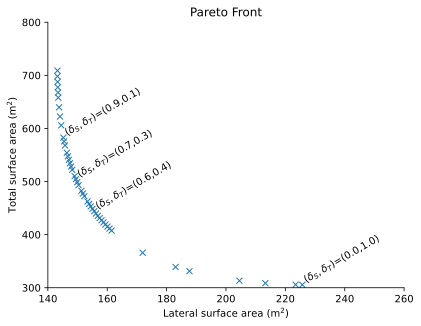

In [10]:
Area_pareto_opt = []
Total_pareto_opt = []
for i in range(len(x_pareto_opt)):
    Area_pareto_opt.append(Area(x_pareto_opt[i]))
    Total_pareto_opt.append(Total(x_pareto_opt[i]))

plt.figure()
plt.plot(Area_pareto_opt,Total_pareto_opt,'x')
for i in range(len(x_pareto_opt)):
    if i%10 == 0:
        plt.annotate(f"($\delta_S,\delta_T$)=({round(delta_Area_opt[i],1)},{round(delta_Total_opt[i],1)})", (Area_pareto_opt[i], Total_pareto_opt[i]), ha='left',va = 'bottom',rotation=30)
plt.xlabel('Lateral surface area (m$^2$)')
plt.ylabel('Total surface area (m$^2$)')
plt.title('Pareto Front')
ax = plt.gca()
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.set_xlim([140,260]);
ax.set_ylim([300,800]);

Please note that a lot of non-pareto optimal results are found too, which can be shown by not limiting the axis:

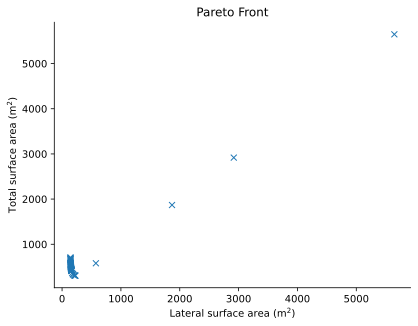

In [11]:
plt.figure()
plt.plot(Area_pareto_opt,Total_pareto_opt,'x')
plt.xlabel('Lateral surface area (m$^2$)')
plt.ylabel('Total surface area (m$^2$)')
plt.title('Pareto Front')
ax = plt.gca()
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

```{solution-end}
```